# E-Commerce Business Intelligence & SQL Analytics — EDA
**Dataset:** Olist Brazilian E-Commerce (Kaggle) — ~100K orders, 8 relational tables, 2016-2018
**Goal:** Understand the data well enough to design correct SQL KPI queries (revenue, seller performance, delivery SLA, CLV/RFM, churn) before building the pipeline in `src/`.

This notebook expects the real Kaggle CSVs under `data/raw/`. If they aren't present, it falls back to
a small synthetic sample (same schema) purely so every cell in this notebook still runs end-to-end for review.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 4)

import sys
sys.path.insert(0, "..")
from src.config import RAW_FILES
from src.data_loader import load_raw_tables, validate_raw_tables, parse_order_dates

RAW_DIR = "../data/raw" if os.path.exists("../data/raw") else "data/raw"
HAS_REAL_DATA = all(os.path.exists(os.path.join(RAW_DIR, f)) for f in RAW_FILES.values())
print("Real Kaggle dataset found:" , HAS_REAL_DATA)

Real Kaggle dataset found: False


## Step 1 — Load raw tables

In [2]:
if HAS_REAL_DATA:
    tables = load_raw_tables(RAW_DIR)
else:
    # Minimal synthetic fallback so the notebook is fully runnable without the 100K-row download.
    # Swap in the real load_raw_tables() call once data/raw/ is populated from Kaggle.
    from tests.conftest import synthetic_tables as _fixture
    import inspect
    rng = np.random.default_rng(7)
    from datetime import datetime, timedelta
    base = datetime(2017, 1, 1)
    n = 400
    cust_ids = [f"c{i}" for i in range(80)]
    customers = pd.DataFrame({"customer_id": cust_ids,
                               "customer_unique_id": [f"u{i%60}" for i in range(80)],
                               "customer_city": ["city"]*80,
                               "customer_state": np.random.choice(["SP","RJ","MG","RS","BA"], 80)})
    order_ids = [f"o{i}" for i in range(n)]
    pts = [base + timedelta(days=int(d)) for d in rng.integers(0, 600, n)]
    orders = pd.DataFrame({"order_id": order_ids, "customer_id": rng.choice(cust_ids, n),
                            "order_status": "delivered",
                            "order_purchase_timestamp": pts, "order_approved_at": pts,
                            "order_delivered_carrier_date": [t+timedelta(days=1) for t in pts],
                            "order_delivered_customer_date": [t+timedelta(days=int(d)) for t,d in zip(pts, rng.integers(2,20,n))],
                            "order_estimated_delivery_date": [t+timedelta(days=10) for t in pts]})
    sellers = pd.DataFrame({"seller_id": [f"s{i}" for i in range(15)], "seller_city": ["city"]*15,
                             "seller_state": np.random.choice(["SP","RJ","MG","RS","BA"], 15)})
    products = pd.DataFrame({"product_id": [f"p{i}" for i in range(30)],
                              "product_category_name": np.random.choice(["bed_bath_table","health_beauty","sports_leisure","furniture_decor"], 30)})
    order_items = pd.DataFrame({"order_id": order_ids, "order_item_id": 1,
                                 "product_id": rng.choice(products.product_id, n),
                                 "seller_id": rng.choice(sellers.seller_id, n),
                                 "price": rng.uniform(20, 400, n).round(2),
                                 "freight_value": rng.uniform(5, 50, n).round(2)})
    payments = pd.DataFrame({"order_id": order_ids, "payment_type": np.random.choice(["credit_card","boleto","voucher"], n),
                              "payment_installments": rng.integers(1,10,n),
                              "payment_value": order_items.price + order_items.freight_value})
    reviews = pd.DataFrame({"review_id": [f"r{i}" for i in range(n)], "order_id": order_ids,
                             "review_score": rng.integers(1,6,n)})
    geolocation = pd.DataFrame({"geolocation_zip_code_prefix":[1000],"geolocation_lat":[-20.0],"geolocation_lng":[-45.0]})
    category_translation = pd.DataFrame({"product_category_name": ["bed_bath_table","health_beauty","sports_leisure","furniture_decor"],
                                          "product_category_name_english": ["Bed Bath Table","Health Beauty","Sports Leisure","Furniture Decor"]})
    tables = {"customers":customers, "orders":orders, "order_items":order_items, "payments":payments,
              "reviews":reviews, "products":products, "sellers":sellers, "geolocation":geolocation,
              "category_translation":category_translation}

for k, v in tables.items():
    print(f"{k:22s} shape={v.shape}")

customers              shape=(80, 4)
orders                 shape=(400, 8)
order_items            shape=(400, 6)
payments               shape=(400, 4)
reviews                shape=(400, 3)
products               shape=(30, 2)
sellers                shape=(15, 3)
geolocation            shape=(1, 3)
category_translation   shape=(4, 2)


## Step 2 — Schema validation (fail fast before any analysis)

In [3]:
validate_raw_tables(tables)
tables["orders"] = parse_order_dates(tables["orders"])
print("Schema validation passed.")

Schema validation passed.


## Step 3 — Data quality gate (referential integrity + null checks)

In [4]:
from src.data_quality_check import run_data_quality_gate
report = run_data_quality_gate(tables, fail_hard=False)
report

{'passed': True, 'violation_count': 0, 'violations': []}

## Step 4 — Order status distribution\nOlist has ~97% `delivered` orders in the real dataset — everything downstream filters to `delivered` to avoid counting cancelled/unavailable orders as revenue.

In [5]:
tables["orders"]["order_status"].value_counts(normalize=True).round(3)

order_status
delivered    1.0
Name: proportion, dtype: float64

## Step 5 — Missing value audit

In [6]:
for name, df in tables.items():
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f"\n{name}:")
        print(nulls)

## Step 6 — Orders per month (volume trend)

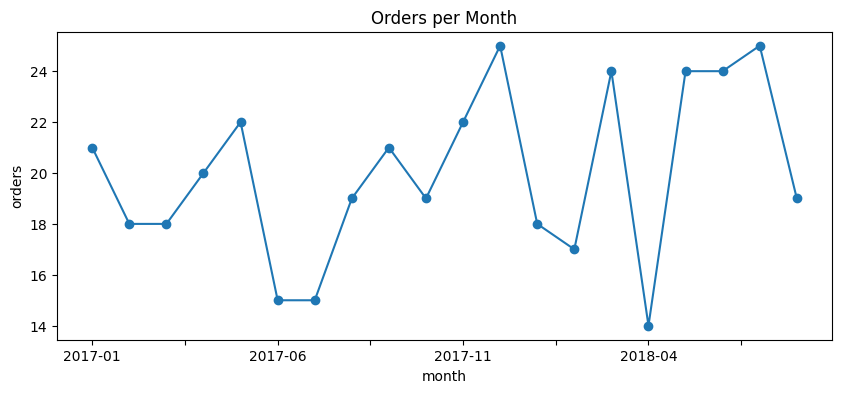

In [7]:
delivered = tables["orders"][tables["orders"]["order_status"]=="delivered"].copy()
delivered["month"] = delivered["order_purchase_timestamp"].dt.to_period("M").astype(str)
monthly_orders = delivered.groupby("month").size()
monthly_orders.plot(kind="line", marker="o", title="Orders per Month")
plt.ylabel("orders"); plt.show()

## Step 7 — Revenue per order distribution (order_items joined)

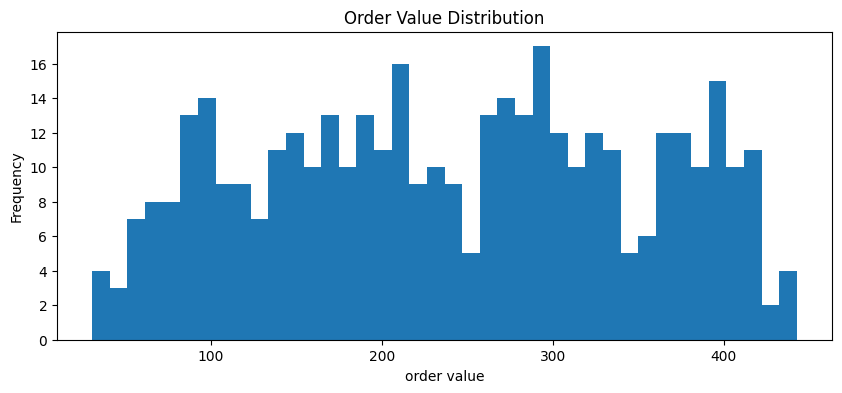

count    400.000000
mean     240.027025
std      109.045040
min       30.650000
25%      148.512500
50%      237.225000
75%      327.532500
max      442.650000
dtype: float64

In [8]:
order_value = (tables["order_items"].groupby("order_id")
               .apply(lambda g: (g["price"]+g["freight_value"]).sum()))
order_value.plot(kind="hist", bins=40, title="Order Value Distribution")
plt.xlabel("order value"); plt.show()
order_value.describe()

## Step 8 — Revenue by customer state

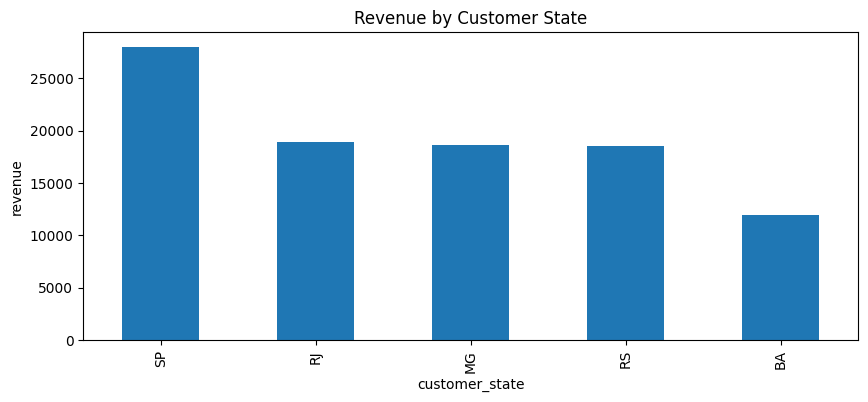

In [9]:
merged = delivered.merge(tables["customers"], on="customer_id").merge(
    tables["order_items"], on="order_id")
merged["order_value"] = merged["price"] + merged["freight_value"]
state_rev = merged.groupby("customer_state")["order_value"].sum().sort_values(ascending=False)
state_rev.plot(kind="bar", title="Revenue by Customer State")
plt.ylabel("revenue"); plt.show()

## Step 9 — Top product categories by revenue

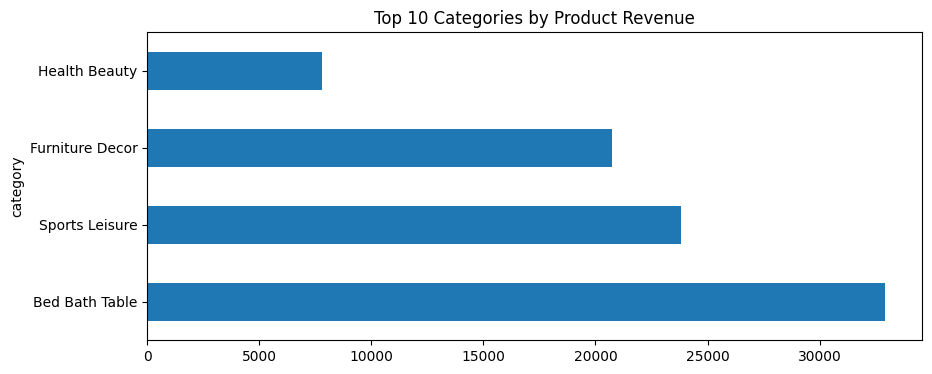

In [10]:
cat_merge = merged.merge(tables["products"], on="product_id").merge(
    tables["category_translation"], on="product_category_name", how="left")
cat_merge["category"] = cat_merge["product_category_name_english"].fillna(cat_merge["product_category_name"])
top_cats = cat_merge.groupby("category")["price"].sum().sort_values(ascending=False).head(10)
top_cats.plot(kind="barh", title="Top 10 Categories by Product Revenue")
plt.show()

## Step 10 — Delivery time distribution (purchase -> delivered)

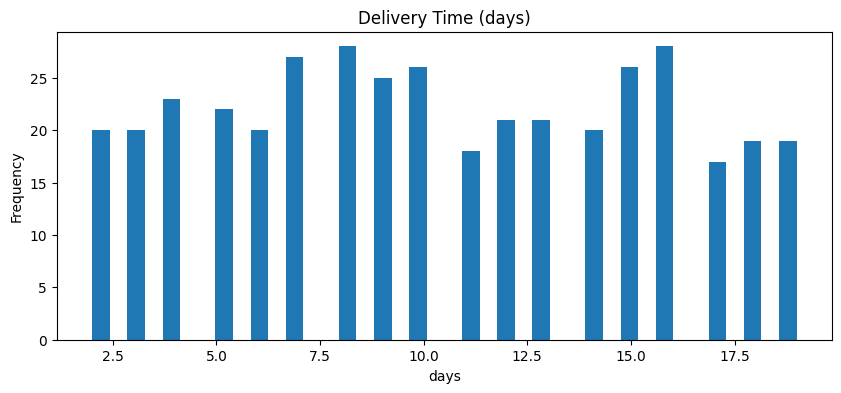

count    400.000000
mean      10.382500
std        5.040308
min        2.000000
25%        6.000000
50%       10.000000
75%       15.000000
max       19.000000
dtype: float64

In [11]:
delivery_days = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
delivery_days.plot(kind="hist", bins=40, title="Delivery Time (days)")
plt.xlabel("days"); plt.show()
delivery_days.describe()

## Step 11 — Late delivery rate

In [12]:
is_late = delivered["order_delivered_customer_date"] > delivered["order_estimated_delivery_date"]
print(f"Late delivery rate: {is_late.mean()*100:.2f}%")

Late delivery rate: 47.25%


## Step 12 — Delivery time vs review score (does slow delivery hurt reviews?)

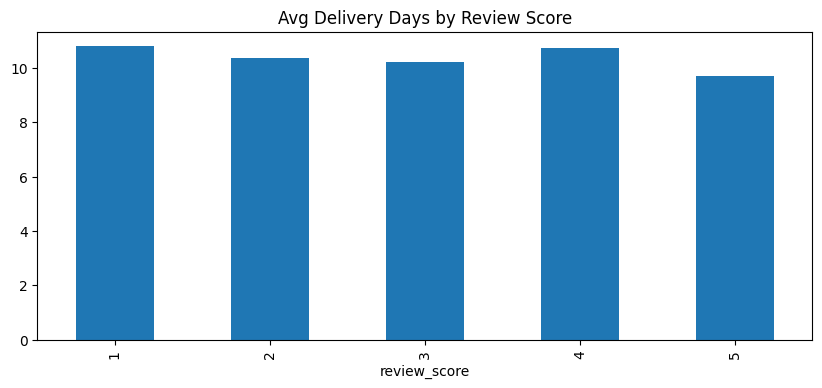

In [13]:
rev_delivery = delivered.merge(tables["reviews"], on="order_id")
rev_delivery["delivery_days"] = (rev_delivery["order_delivered_customer_date"] - rev_delivery["order_purchase_timestamp"]).dt.days
rev_delivery.groupby("review_score")["delivery_days"].mean().plot(kind="bar", title="Avg Delivery Days by Review Score")
plt.show()

## Step 13 — Seller order volume distribution (long tail check)

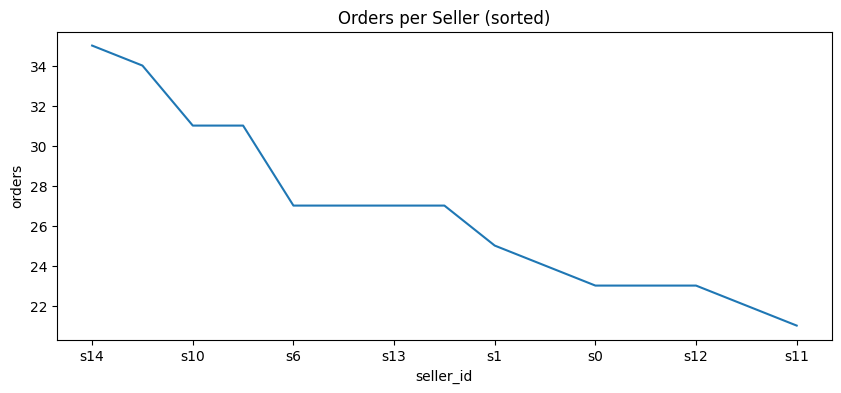

Sellers with < 5 orders: 0.0% of sellers


In [14]:
seller_orders = tables["order_items"].groupby("seller_id")["order_id"].nunique().sort_values(ascending=False)
seller_orders.plot(title="Orders per Seller (sorted)")
plt.ylabel("orders"); plt.show()
print(f"Sellers with < 5 orders: {(seller_orders < 5).mean()*100:.1f}% of sellers")

## Step 14 — Seller revenue concentration (Pareto check)

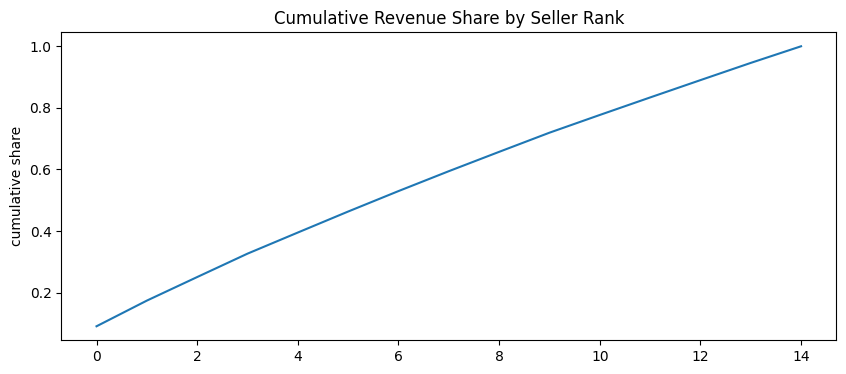

In [15]:
seller_rev = merged.groupby("seller_id")["order_value"].sum().sort_values(ascending=False) if "seller_id" in merged.columns else tables["order_items"].groupby("seller_id").apply(lambda g:(g.price+g.freight_value).sum()).sort_values(ascending=False)
cum_share = seller_rev.cumsum() / seller_rev.sum()
cum_share.reset_index(drop=True).plot(title="Cumulative Revenue Share by Seller Rank")
plt.ylabel("cumulative share"); plt.show()

## Step 15 — Payment type breakdown

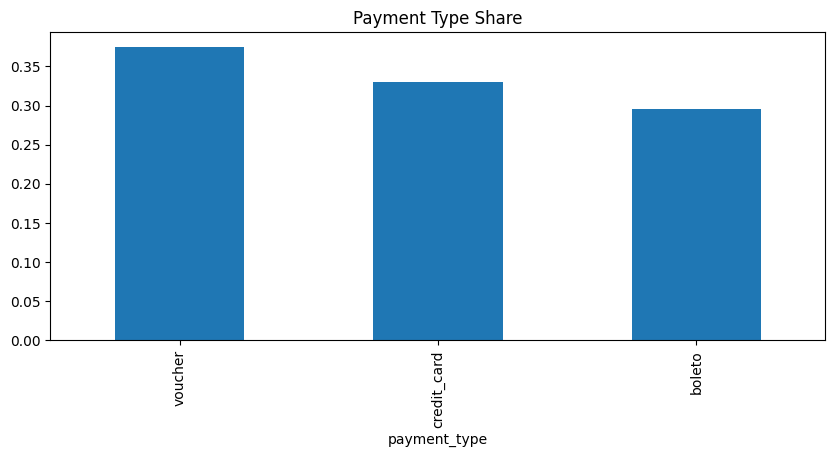

In [16]:
tables["payments"]["payment_type"].value_counts(normalize=True).round(3).plot(kind="bar", title="Payment Type Share")
plt.show()

## Step 16 — Installments distribution

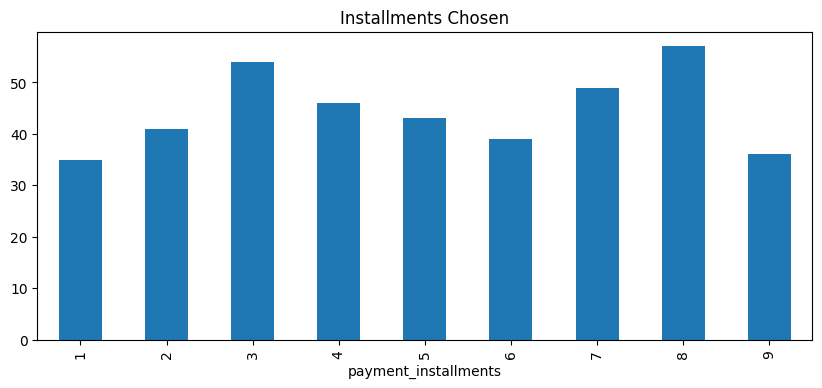

In [17]:
tables["payments"]["payment_installments"].value_counts().sort_index().plot(kind="bar", title="Installments Chosen")
plt.show()

## Step 17 — Review score distribution

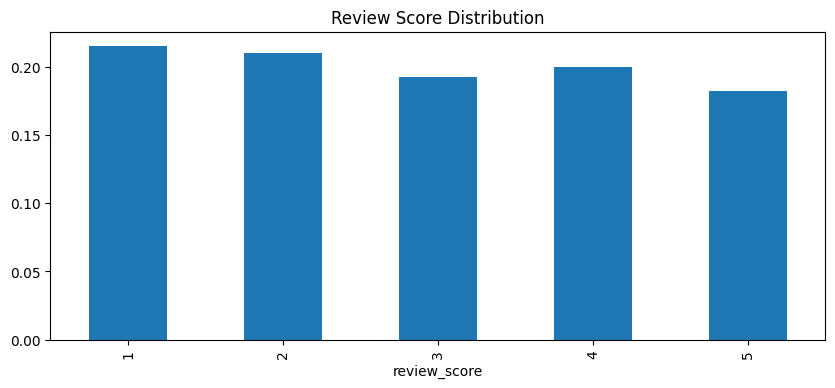

In [18]:
tables["reviews"]["review_score"].value_counts(normalize=True).sort_index().plot(kind="bar", title="Review Score Distribution")
plt.show()

## Step 18 — Repeat customers (customer_unique_id) — CLV signal check

In [19]:
cust_order_counts = tables["orders"].merge(tables["customers"], on="customer_id").groupby("customer_unique_id")["order_id"].nunique()
repeat_rate = (cust_order_counts > 1).mean()
print(f"Repeat purchase rate: {repeat_rate*100:.2f}%")
cust_order_counts.value_counts().sort_index().head(10)

Repeat purchase rate: 93.22%


order_id
1      4
2      2
3      3
4      9
5     10
6      5
7      5
8      3
9      4
10     3
Name: count, dtype: int64

## Step 19 — Price outlier check (IQR-based, informs whether clipping is warranted)

In [20]:
q1, q3 = tables["order_items"]["price"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5*iqr
outlier_pct = (tables["order_items"]["price"] > upper).mean()
print(f"Price outliers beyond 1.5*IQR: {outlier_pct*100:.2f}% of line items")

Price outliers beyond 1.5*IQR: 0.00% of line items


## Step 20 — Freight cost as % of price, by category (logistics efficiency signal)

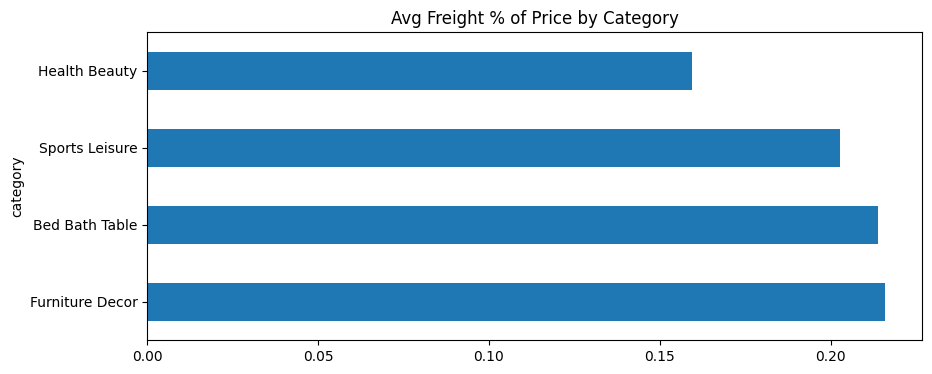

In [21]:
cat_merge["freight_pct"] = cat_merge["freight_value"] / cat_merge["price"].replace(0, np.nan)
cat_merge.groupby("category")["freight_pct"].mean().sort_values(ascending=False).head(10).plot(kind="barh", title="Avg Freight % of Price by Category")
plt.show()

## Step 21 — Geolocation sanity check (lat/lng bounds for Brazil)

In [22]:
geo = tables["geolocation"]
print(geo[["geolocation_lat","geolocation_lng"]].describe())

       geolocation_lat  geolocation_lng
count              1.0              1.0
mean             -20.0            -45.0
std                NaN              NaN
min              -20.0            -45.0
25%              -20.0            -45.0
50%              -20.0            -45.0
75%              -20.0            -45.0
max              -20.0            -45.0


## Step 22 — Correlation: price vs freight vs review score vs delivery days

In [23]:
corr_df = rev_delivery[["price","freight_value","review_score","delivery_days"]] if "price" in rev_delivery.columns else None
if corr_df is None:
    corr_df = rev_delivery.merge(tables["order_items"], on="order_id")[["price","freight_value","review_score","delivery_days"]]
corr_df.corr().round(2)

,price,freight_value,review_score,delivery_days
price,1.00,-0.07,0.10,-0.03
freight_value,-0.07,1.00,-0.02,0.02
review_score,0.10,-0.02,1.00,-0.05
delivery_days,-0.03,0.02,-0.05,1.00


## Step 23 — Duplicate / referential-integrity spot checks

In [24]:
dupe_orders = tables["orders"]["order_id"].duplicated().sum()
orphan_items = set(tables["order_items"]["order_id"]) - set(tables["orders"]["order_id"])
print(f"Duplicate order_id rows: {dupe_orders}")
print(f"Order items pointing to non-existent orders: {len(orphan_items)}")

Duplicate order_id rows: 0
Order items pointing to non-existent orders: 0


## Step 24 — Key takeaways feeding the SQL KPI design (sql/*.sql)\n- Filter to `order_status = 'delivered'` for all revenue/CLV KPIs — cancelled/unavailable orders should not count as sales.\n- `customer_unique_id` (not `customer_id`) is the correct grain for repeat-purchase / RFM / churn analysis.\n- Seller leaderboards need a minimum-order-count floor — the long tail of 1-2 order sellers would otherwise dominate averages.\n- Late-delivery rate and review score are correlated — worth surfacing together on the seller performance dashboard.\n- Freight-as-%-of-price varies meaningfully by category — a logistics-cost KPI, not just a revenue one.

## Step 25 — Next: build the database + KPI snapshot\nRun the pipeline end-to-end:\n```bash\npython scripts/build_database.py\npython scripts/run_pipeline.py\n```